### Find Maximum Number of Watch Parties (IBM-1)

2026-03-23

We have engagementScores, a list/array of scores

We want to find the maximum number of sub-arrays such that the scores of each sub-array is at least minWatchPartyScore

The score of a party (sub-array) is computed as such:

`"lowest value in subarray" * "length of subarray"`

In [18]:
def findMaxWatchParties(engagementScores: list, minWatchPartyScore: int) -> int:
    maxNumParties = 0
    parties = []
    scores = []

    engagementScores.sort(reverse = True)
    print(f"> Sorted engagementScores (Descending): {engagementScores}\n")

    curr_partySize = 0
    party = []

    for score in engagementScores:
        curr_partySize += 1
        party.append(score)

        if score * curr_partySize >= minWatchPartyScore:
            maxNumParties += 1
            parties.append(party)
            scores.append(score*curr_partySize)

            curr_partySize = 0
            party = []
    
    return maxNumParties, parties, scores

In [21]:
# Test
engagementScores = [10, 2, 19, 3, 4, 5, 12, 19, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
minWatchPartyScore = 10
max_num_parties, parties, scores = findMaxWatchParties(engagementScores, minWatchPartyScore)
print(f">>> Max Number of Parties: {max_num_parties}\n")
print(f">>> Parties: {parties}\n")
print(f">>> Scores: {scores}\n")

> Sorted engagementScores (Descending): [19, 19, 12, 10, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

>>> Max Number of Parties: 6

>>> Parties: [[19], [19], [12], [10], [5, 4, 3, 2, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

>>> Scores: [19, 19, 12, 10, 10, 10]



### Task Allocator / Load Balancing (IBM-2)

2026-03-23

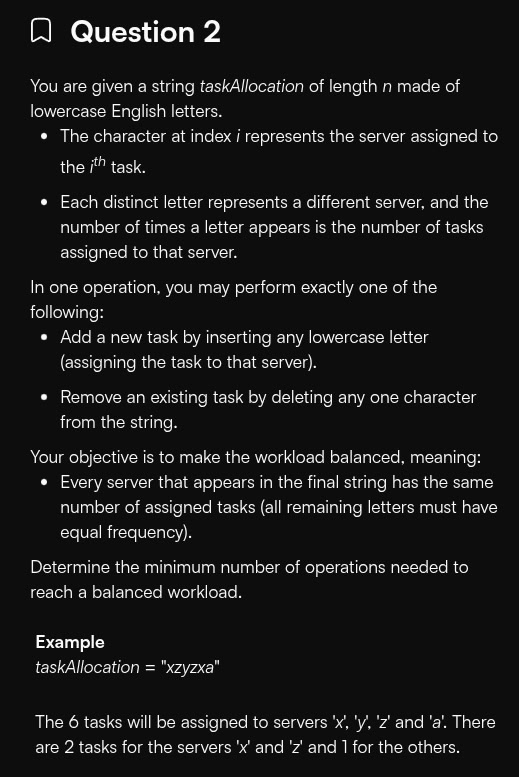

In [ ]:
from collections import Counter

def balanceLoad(taskAllocation):
    min_operations = 0
    
    # key = Server, value = Number of Tasks
    server_taskCount = Counter(taskAllocation)
    print(server_taskCount)
    taskCount = list(Counter(taskAllocation).values())
    # print(taskCount)
    avg = round(sum(taskCount) / len(taskCount))
    # print(avg)
    
    for count in taskCount:
        if count != avg:
            min_operations += abs(count-avg)
    
    balanced = [avg] * len(taskCount)
    print(balanced)
    
    return min_operations

tests = ["xzyzxabbb", "xzyzxabbbddd", "aabbccc", "abcddeeffggghhhiiijjjj"]
for taskAllocation in tests:
    print(balanceLoad(taskAllocation), "\n")

Counter({'b': 3, 'x': 2, 'z': 2, 'y': 1, 'a': 1})
[2, 2, 2, 2, 2]
3 

Counter({'b': 3, 'd': 3, 'x': 2, 'z': 2, 'y': 1, 'a': 1})
[2, 2, 2, 2, 2, 2]
4 

Counter({'c': 3, 'a': 2, 'b': 2})
[2, 2, 2]
1 

Counter({'j': 4, 'g': 3, 'h': 3, 'i': 3, 'd': 2, 'e': 2, 'f': 2, 'a': 1, 'b': 1, 'c': 1})
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
8 



### 2026-04-11 (IBM-3)

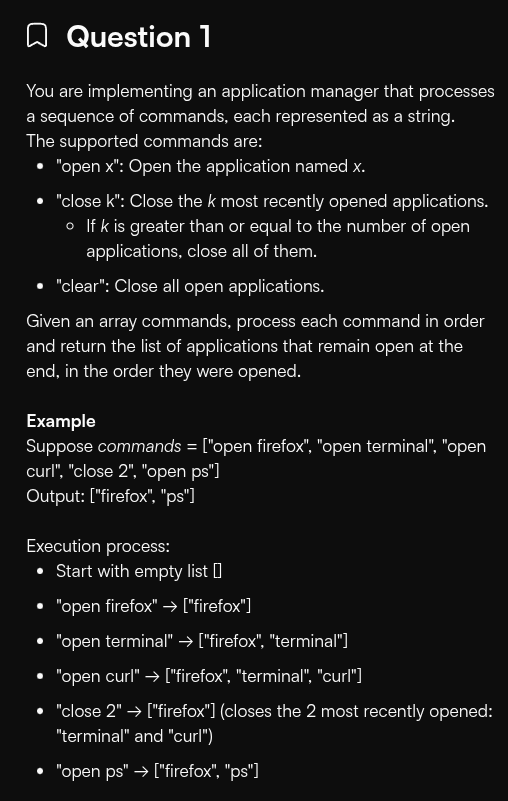

In [ ]:
def getOpenApplications(commands):
    open_apps = []
    
    for command in commands:
        if command != "clear":
            c = command.split()
            
            # Open an App
            if c[0] == "open":
                open_apps.append(c[1])
            
            elif c[0] == "close":
                k = int(c[1])
                if k < len(open_apps):
                    for i in range(k):
                        open_apps.pop()
                else:
                    open_apps = []
            
        else:
            # Clear all open applications
            open_apps = []
         
    return open_apps

### 2026-04-11 (IBM-4)

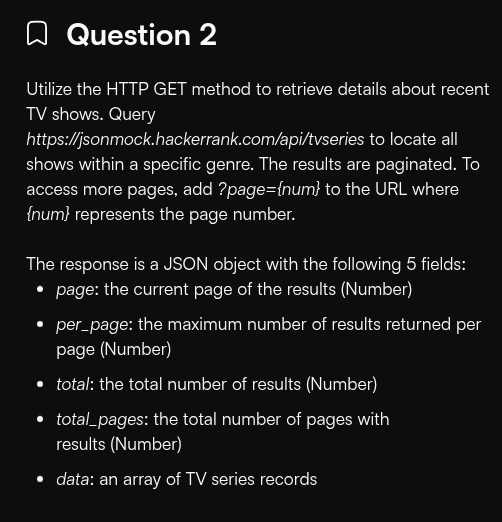

https://realpython.com/api-integration-in-python

In [ ]:
import requests

def bestInGenre(genre):
    url = "https://jsonmock.hackerrank.com/api/tvseries"
    result = requests.get(url).json()
    total_pages = result["total_pages"]
    data = result["data"]
    # print(f"Total pages: {total_pages}")
    # print(f"Data: {data}")
    # for show in data:
    #     print(show["name"])
    
    genre_shows = []
    
    base_url = "https://jsonmock.hackerrank.com/api/tvseries?page="
    for page in range(1, total_pages):
        url = base_url + str(page)
        result = requests.get(url).json()
        data = result["data"]
        
        for show in data:
            if genre in show["genre"]:
                genre_shows.append([show["imdb_rating"], show["name"]])
    
    genre_shows.sort(key = lambda x : (-x[0], x[1]))
    print("genre_shows > ", genre_shows)
    
    return genre_shows[0][1]

### 49. Group Anagrams

[49. Group Anagrams](https://leetcode.com/problems/group-anagrams/)

2026-04

*Tuples can be used as dictionary keys

- Dictionary with key as tuple of sorted characters in each string, value as list of strings

In [9]:
from collections import defaultdict

def groupAnagrams(strs: list[str]) -> list[list[str]]:
    tupleAnagrams = defaultdict(list)

    for i in strs:
        tupleAnagrams[ tuple(sorted(i)) ].append(i)
    
    return list(tupleAnagrams.values())

In [10]:
# Test
tests = [ ["eat","tea","tan","ate","nat","bat"],
          [""], 
          ["a"], 
          ["eat","tea","tan","ate","nat","bat", "bataaa"]
        ]
for test in tests:
    print(f">>> {groupAnagrams(test)}")

>>> [['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat']]
>>> [['']]
>>> [['a']]
>>> [['eat', 'tea', 'ate'], ['tan', 'nat'], ['bat'], ['bataaa']]


### 3. Longest Substring Without Repeating Characters

[3. Longest Substring Without Repeating Characters](https://leetcode.com/problems/longest-substring-without-repeating-characters/)

2026-04

In [7]:
def lengthOfLongestSubstring(s: str) -> int:
    unique = set()
    left = 0
    curr_max = 0

    for right in range(len(s)):
        while s[right] in unique:
            unique.remove(s[left])
            left += 1
        unique.add(s[right])
        print(f"Left: {s[left]} ({left}) | Right: {s[right]} ({right}) | Current: {s[0:right+1]}") 
        print(f"unique: {unique}")
        curr_max = max(curr_max, len(unique))
    return curr_max

# Test
# tests = [ "abcabcbb", "bbbbb", "pwwkew" ]
# for test in tests:
#     print(f">>> {lengthOfLongestSubstring(test)}")

lengthOfLongestSubstring("pazoqtwwwkew")


Left: p (0) | Right: p (0) | Current: p
unique: {'p'}
Left: p (0) | Right: a (1) | Current: pa
unique: {'a', 'p'}
Left: p (0) | Right: z (2) | Current: paz
unique: {'z', 'a', 'p'}
Left: p (0) | Right: o (3) | Current: pazo
unique: {'o', 'z', 'a', 'p'}
Left: p (0) | Right: q (4) | Current: pazoq
unique: {'a', 'q', 'o', 'z', 'p'}
Left: p (0) | Right: t (5) | Current: pazoqt
unique: {'a', 't', 'q', 'o', 'z', 'p'}
Left: p (0) | Right: w (6) | Current: pazoqtw
unique: {'a', 't', 'q', 'o', 'z', 'w', 'p'}
Left: w (7) | Right: w (7) | Current: pazoqtww
unique: {'w'}
Left: w (8) | Right: w (8) | Current: pazoqtwww
unique: {'w'}
Left: w (8) | Right: k (9) | Current: pazoqtwwwk
unique: {'k', 'w'}
Left: w (8) | Right: e (10) | Current: pazoqtwwwke
unique: {'k', 'w', 'e'}
Left: k (9) | Right: w (11) | Current: pazoqtwwwkew
unique: {'k', 'w', 'e'}


7

### 347. Top K Frequent Elements

[347. Top K Frequent Elements](https://leetcode.com/problems/top-k-frequent-elements/)

2026-04

In [ ]:
from collections import defaultdict

def topKFrequent(nums: list[int], k: int) -> list[int]:
    numCount = defaultdict(int)
    for i in nums:
        numCount[i] += 1

    top = sorted( list(numCount.items()), key = lambda pair: pair[1], reverse = True)[0:k]

    return [pair[0] for pair in top]

topKFrequent([1,1,1,2,2,3,4,4,4,4,4,5,5,10,12,2,1,1,1,1], 2)

[1, 4]

Best performing answer.

In [26]:
from collections import Counter

def topKFrequent(nums: list[int], k: int) -> list[int]:
    freq_dict = Counter(nums)
    print(f"freq_dict: {freq_dict}")

    result = freq_dict.most_common(k)
    result_list = []

    for i in result:
        result_list.append(i[0])
    
    return result_list

topKFrequent([1,1,1,2,2,3,4,4,4,4,4,5,5,10,12,2,1,1,1,1], 2)

freq_dict: Counter({1: 7, 4: 5, 2: 3, 5: 2, 3: 1, 10: 1, 12: 1})


[1, 4]

### 56. Merge Intervals

[56. Merge Intervals](https://leetcode.com/problems/merge-intervals/)

2026-04

In [ ]:
# subarrays [a, b] and [x, y] overlap if either:
# a <= x <= b
# x <= b <= y

def merge(intervals: list[int]) -> list[int]:
    prev = list()
    merged = list()

    for i in sorted(intervals):
        if not prev:
            prev = i
        elif (prev[0] <= i[0] and i[0] <= prev[1]) or (i[0] <= prev[1] and prev[1] <= i[1]):
            prev = [min(prev[0], i[0]), max(prev[1], i[1])]       
        else:
            merged.append(prev)
            prev = i

    merged.append(prev)
    return merged

Best performing answer.

In [27]:
def merge(intervals: list[int]) -> list[int]:
    merged = []
    intervals.sort(key = lambda x: x[0])

    prev = intervals[0]

    for i in intervals[1:]:
        if i[0] <= prev[1]:
            prev[1] = max(prev[1], i[1])
        else:
            merged.append(prev)
            prev = i
        print(prev)
    
    merged.append(prev)

    return merged

test = [[1,3],[2,6],[8,10],[15,18],[4,7]]
merge(test)

[1, 6]
[1, 7]
[8, 10]
[15, 18]


[[1, 7], [8, 10], [15, 18]]

### Minimum Platforms Required

[Minimum Platforms Required](https://www.geeksforgeeks.org/minimum-number-platforms-required-railwaybus-station/)

2026-04

Sweep Line Algorithm

In [ ]:
def minPlatforms(arrivals, departures):
    platforms = 0
    min_platforms = 0

    time_action = sorted( list(zip(arrivals, "a"*len(arrivals))) + list(zip(departures, "d"*len(departures))) )

    for t in time_action:
        if t[1] == "a":
            platforms += 1
        else:
            platforms -= 1
        
        min_platforms = max(min_platforms, platforms)

    return min_platforms

In [41]:
arr = [900, 920, 939, 940, 941, 950, 1100, 1500, 1800]
dep = [910, 930, 940, 1200, 1300, 1120, 1130, 1900, 2000]
print(f"Minimum number of platforms: {minPlatforms(arr, dep)}")

Minimum number of platforms: 4


Reference answer

In [ ]:
def minPlatform(arr, dep):
    n = len(arr)
    res = 0

    # Find the max Departure time 
    maxDep = max(dep)
    v = [0] * (maxDep + 2)
    
    # Increment the count at the arrival time and decrement
    # at the departure time
    for i in range(n):
        v[arr[i]] += 1
        v[dep[i] + 1] -= 1
    
    count = 0

    # Iterate over the list and keep track of the maximum sum seen so far
    for i in range(maxDep + 2):
        count += v[i]
        res = max(res, count)
    
    return res

arr = [900, 920, 939, 940, 941, 950, 1100, 1500, 1800]
dep = [910, 930, 940, 1200, 1300, 1120, 1130, 1900, 2000]
print(minPlatform(arr, dep))

4


### 77. Combinations

[77. Combinations](https://leetcode.com/problems/combinations/description/)

2026-04

In [18]:
def combine(n: int, k: int):
    combinations = []
    curr = []
    find_combination(1, n, k, curr, combinations)
    return combinations

def find_combination(i, n, k, curr, combinations):
    print(curr, ">", i)
    if len(curr) == k:
        combinations.append(curr.copy())
        return
    
    for j in range(i, n+1):
        if j not in curr:
            curr.append(j)
            find_combination(j+1, n, k, curr, combinations)
            curr.pop()

In [19]:
n, k = 4, 2
combinations = combine(n, k)
print(f"Number of combinations: {len(combinations)}")

[] > 1
[1] > 2
[1, 2] > 3
[1, 3] > 4
[1, 4] > 5
[2] > 3
[2, 3] > 4
[2, 4] > 5
[3] > 4
[3, 4] > 5
[4] > 5
Number of combinations: 6


In [7]:
def combine_2(n: int, k: int):
    combinations = []
    
    def find_combination(remaining, combination, next):    
        if remaining == 0:
            combinations.append(combination.copy())
        
        else:
            for i in range(next, n + 1):
                combination.append(i)
                find_combination(remaining - 1, combination, i + 1)
                combination.pop()

    find_combination(remaining = k, combination = [], next = 1)
    return combinations


In [ ]:
n, k = 20, 3
combinations = combine(n, k)
print(f"Number of combinations: {len(combinations)}")
combinations = combine_2(n, k)
print(f"Number of combinations: {len(combinations)}")

Number of combinations: 1140
Number of combinations: 1140


### 238. Product of Array Except Self

[238. Product of Array Except Self](https://leetcode.com/problems/product-of-array-except-self)

Prefix and Suffix Product

2026-04

In [ ]:
def productExceptSelf(nums: list[int]) -> list[int]:
    product = [0] * len(nums)

    before = 1
    for i in range(len(nums)):
        product[i] = before
        before *= nums[i]

    after = 1
    for j in range(len(nums)-1, -1, -1):
        product[j] *= after
        after *= nums[j]

    return product

### 1071. Greatest Common Divisor of Strings

[1071. Greatest Common Divisor of Strings](https://leetcode.com/problems/greatest-common-divisor-of-strings)

Euclidean Algorithm to find greatest common divisor

2026-04

In [ ]:
def gcdOfStrings(str1: str, str2: str) -> str:
    if str1 + str2 != str2 + str1:
        return ""
    
    def gcd(length1, length2):
        while length2:
            print(f"{length1}, {length2} >>> ", end = "")
            length1, length2 = length2, length1 % length2
            print(f"{length1}, {length2}")
        return length1
    
    return str1[:gcd(len(str1), len(str2))]

### 316. Remove Duplicate Letters

[316. Remove Duplicate Letters](https://leetcode.com/problems/remove-duplicate-letters)

Monotonic Stack

2026-04

In [ ]:
def removeDuplicateLetters(self, s: str) -> str:
    letters = Counter(s)
    stack = []

    for c in s:
        print(stack, " >>>", end=" ")
        letters[c] -= 1
        if c in stack:
            continue
        while stack and stack[-1] > c and letters[stack[-1]] > 0:
            stack.pop()
        stack.append(c)
        print(stack)
    return "".join(stack)

### 2696. Minimum String Length After Removing Substrings

[2696. Minimum String Length After Removing Substrings](https://leetcode.com/problems/minimum-string-length-after-removing-substrings/description/)

2026-04

In [ ]:
def minLength(s: str):
    AB = "AB"
    CD = "CD"
    stack = []
    for i in s:
        if len(stack) > 0:
            curr = stack[-1] + i
            if curr == AB or curr == CD:
                stack.pop()
                continue
        stack.append(i)
    return stack

In [ ]:
def minLength(s: str):
    stack = []
    for ch in s:
        if ch == 'B' and stack and stack[-1] == "A":
            stack.pop()
        elif ch == "D" and stack and stack[-1] == "C":
            stack.pop()
        else:
            stack.append(ch)
    return stack

The solution implementation is the same if:
- The input string only contains "A" or "B"
- Remove substrings "AB" or "BB"

In [4]:
def minLength(s: str) -> int:
    AB, BB = "AB", "BB"
    stack = []
    for ch in s:
        if len(stack) > 0:
            curr = stack[-1] + ch
            if curr == AB or curr == BB:
                stack.pop()
                continue
        stack.append(ch)
    return stack

In [5]:
s = "AABBBAABABABABABBBBBAAAABBBBABABABBBBAAABABABABABABABAA"
minLength(s)

['B', 'A', 'A', 'A', 'A']

### 1004. Max Consecutive Ones III

[1004. Max Consecutive Ones III](https://leetcode.com/problems/max-consecutive-ones-iii)

2026-04

In [5]:
def longestOnes(nums, k):
    l, r = 0, 0
    maxOnes = 0
    curr_zeroes = 0

    while (r < len(nums)):
        if nums[r] == 0:
            curr_zeroes += 1

        if curr_zeroes > k:
            if nums[l] == 0:
                curr_zeroes -= 1
            l += 1

        if curr_zeroes <= k:
            maxOnes = max(maxOnes, r - l + 1)

        r += 1
        print(f">>> {l}, {r}, > {maxOnes}")
    
    return maxOnes

In [ ]:
def longestOnes(nums, k):        
    left = 0
    zeroCount = 0
    for right in nums:
        if right == 0:
            zeroCount += 1
        if zeroCount > k:
            if nums[left] == 0:
                zeroCount -= 1
            left += 1
    return len(nums) - left

In [6]:
nums = [1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0]
k = 2
longestOnes(nums, k)

>>> 0, 1, > 1
>>> 0, 2, > 2
>>> 0, 3, > 3
>>> 0, 4, > 4
>>> 0, 5, > 5
>>> 1, 6, > 5
>>> 2, 7, > 5
>>> 3, 8, > 5
>>> 4, 9, > 5
>>> 4, 10, > 6
>>> 5, 11, > 6


6

### 334. Increasing Triplet Subsequence

[334. Increasing Triplet Subsequence](https://leetcode.com/problems/increasing-triplet-subsequence)

2026-04

In [ ]:
def increasingTriplet(self, nums: list[int]) -> bool:
    first, second = float('inf'), float('inf')
    for num in nums:
        if num <= first:
            first = num
        elif num <= second:
            second = num
        else:
            return True
    return False

### 394. Decode String

[394. Decode String](https://leetcode.com/problems/decode-string) - Stack

2026-05

In [ ]:
def decodeString(self, s: str) -> str:
    stack = []
    for i in range(len(s)):
        if s[i] != "]":
            stack.append(s[i])
        else:
            substring = ""
            # Getting the alphabet string
            while stack[-1] != "[":
                x = stack.pop()
                substring = x + substring
            stack.pop() # For removing opening bracket "["

            # Getting number
            k = ""
            while stack and stack[-1].isnumeric():
                digit = stack.pop()
                k = digit + k
            stack.append(int(k) * substring)
        # print(f">> {stack}")
    
    return "".join(stack)

### 739. Daily Temperatures

[739. Daily Temperatures](https://leetcode.com/problems/daily-temperatures) - Monotonic Stack

2026-05

In [ ]:
def dailyTemperatures(temperatures: list[int]) -> list[int]:
    l = len(temperatures)
    mono_stack = []
    index_stack = []
    ans = [0] * l
    
    for i in range(l):
        temp = temperatures[i]
        # print(f"> {mono_stack} <- {temp}", end = " : ")
        while mono_stack and mono_stack[-1] < temp:
            mono_stack.pop()
            t = index_stack.pop()
            elapsed = i - t
            # print(elapsed, end = " : ")
            ans[t] = elapsed
        mono_stack.append(temp)
        index_stack.append(i)
        # print(index_stack)
        # print(ans)
    return ans

In [6]:
def dailyTemperatures_(temperatures: list[int]) -> list[int]:
    N = len(temperatures)
    result = [0] * N
    curr_max = temperatures[-1]

    for i in range(N - 1, -1, -1):
        temp = temperatures[i]
        if temp >= curr_max:
            curr_max = temp
        else:
            next_i = i + 1
            while temp >= temperatures[next_i]:
                next_i += result[next_i]
            result[i] = next_i - i
        print(f"> {result}")
    return result

In [7]:
temperatures = [73,74,75,71,69,72,76,73]
dailyTemperatures_(temperatures)

> [0, 0, 0, 0, 0, 0, 0, 0]
> [0, 0, 0, 0, 0, 0, 0, 0]
> [0, 0, 0, 0, 0, 1, 0, 0]
> [0, 0, 0, 0, 1, 1, 0, 0]
> [0, 0, 0, 2, 1, 1, 0, 0]
> [0, 0, 4, 2, 1, 1, 0, 0]
> [0, 1, 4, 2, 1, 1, 0, 0]
> [1, 1, 4, 2, 1, 1, 0, 0]


[1, 1, 4, 2, 1, 1, 0, 0]

### Count Number of Divisible Triplet Sums

[Count Number of Divisible Triplet Sums](https://www.geeksforgeeks.org/dsa/count-number-of-divisible-triplet-sums/)

...

Given a 0-indexed integer array arr[] and an integer d

Return the count number of triplets (i, j, k) such that i < j < k and (arr[i] + arr[j] + arr[k]) % d == 0.

In [27]:
def divisible_triplet_count(arr, d):
    duplet_sums = {}

    for i in range(len(arr)):
        for j in range(i + 1, len(arr)):
            sum_val = (arr[i] + arr[j]) % d
            duplet_sums.setdefault(sum_val, []).append((i, j))

    count = 0
    print(duplet_sums)

    for k in range(len(arr)):
        target_key = (d - arr[k] % d + d) % d

        for ij_pair in duplet_sums.get(target_key, []):
            if ij_pair[1] < k:
                count += 1

    return count

In [28]:
arr = [3, 3, 4, 7, 8]
d = 5
count = divisible_triplet_count(arr, d)
print(f"Number of divisible triplets = {count}")

{1: [(0, 1), (0, 4), (1, 4), (2, 3)], 2: [(0, 2), (1, 2), (2, 4)], 0: [(0, 3), (1, 3), (3, 4)]}
Number of divisible triplets = 3


In [ ]:
from collections import defaultdict

def divisible_triplet_count(arr, d):
    n = len(arr)
    ans = 0

    # key: pair sum % d, value: count
    duplet_sums = defaultdict(int)

    for k in range(1, n):
        # Calculate the expected remainder for the current element to form a divisible triplet
        expected = (d - (arr[k] % d) + d) % d

        # Add the count of pairs with the expected remainder to the answer
        ans += duplet_sums[expected]

        for i in range(k):
            # Calculate the sum of the current element and the previous element modulo d
            x = (arr[i] + arr[k]) % d

            duplet_sums[x] += 1
    
    return ans

In [26]:
arr = [3, 3, 4, 7, 8]
d = 5
count = divisible_triplet_count(arr, d)
print(f"Number of divisible triplets = {count}")

>> arr[k] % d = 3 % 5 = 3
> (5 - (3 % 5) + 5) % 5 = 2
k = 1, value = 3, expected = 2

>> arr[k] % d = 4 % 5 = 4
> (5 - (4 % 5) + 5) % 5 = 1
k = 2, value = 4, expected = 1

>> arr[k] % d = 7 % 5 = 2
> (5 - (7 % 5) + 5) % 5 = 3
k = 3, value = 7, expected = 3

>> arr[k] % d = 8 % 5 = 3
> (5 - (8 % 5) + 5) % 5 = 2
k = 4, value = 8, expected = 2

duplet_sums
defaultdict(<class 'int'>, {2: 3, 1: 4, 3: 0, 0: 3})
Number of divisible triplets = 3


### Throughput Optimization (Visa)

[Visa Question - Throughput Optimization](https://www.reddit.com/r/leetcode/comments/1dxv1iw/failed_this_oa_question/?solution=7b8b643f55688c5c7b8b643f55688c5c&js_challenge=1&token=bbbe4bf1c9a2b5160829c4be34da5861f32e31b165f35147dda6c2a8a563b5b9)

...

### 33. Search in Rotated Sorted Array

[33. Search in Rotated Sorted Array](https://leetcode.com/problems/search-in-rotated-sorted-array/)

...

In [ ]:
def binary_search(array, low, high, target):
    if high >= low:
        mid = low + (high - low) // 2

        if array[mid] == target:
            return mid
        
        elif array[mid] > target:
            return binary_search(array, low, mid-1, target)

        else:
            return binary_search(array, mid+1, high, target)

    else:
        return -1

In [ ]:
array = [-22, 1, 21, 29, 46, 53, 67, 69, 101]
low, high = 0, len(array)
target = 67
print(binary_search(array, low, high, target))

6


### 200. Number of Islands

[200. Number of Islands](https://leetcode.com/problems/number-of-islands/)

### 994. Rotting Oranges

[994. Rotting Oranges](https://leetcode.com/problems/rotting-oranges/)